# Sequential ViDA: IDRiD → APTOS → Messidor (VisionFM)

Protocol:
1. Load VisionFM pretrained weights
2. Evaluate baseline on source domain (IDRiD)
3. Adapt to target domain (APTOS) - adaptation mode
4. Adapt to target domain (Messidor-2) - adaptation mode
5. Evaluate on ALL previous domains - TEST mode

This measures cumulative adaptation across 3 domains.

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/sequential/vida/idrid_aptos_messidor_visionfm.yaml')

print('Protocol: Sequential ViDA')
print(f'Source: {config.sequential.source_dataset.name}')
print(f'Targets: {[t.name for t in config.sequential.target_datasets]}')
print('Method:', config.ctta.method)
print('Output:', config.output_dir)

# RETFound weights are gated behind HuggingFace; require a token.
if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')
elif config.model.name != 'retfound':
    print('No HF token needed (VisionFM / Google Drive)')

Protocol: Sequential ViDA
Source: idrid
Targets: ['aptos2019', 'messidor2']
Method: cotta
Output: ./outputs/sequential_vida/idrid_aptos_messidor_visionfm/
No HF token needed (VisionFM / Google Drive)


In [4]:
from src.evaluation.runner import SequentialCTTARunner

runner = SequentialCTTARunner(config)
results = runner.run()

2026-08-05 17:45:34,178 - src.evaluation.runner.sequential - INFO - Starting sequential CTTA: idrid -> aptos2019 -> messidor2
2026-08-05 17:45:34,467 - src.models.visionfm_download - INFO - Downloading VisionFM Fundus weights from Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=13uWm0a02dCWyARUcrCdHZIcEgRfBmVA4
From (redirected): https://drive.google.com/uc?id=13uWm0a02dCWyARUcrCdHZIcEgRfBmVA4&confirm=t&uuid=97fc746d-b7f5-471f-9920-c447f25ed355
To: /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
100%|██████████| 1.51G/1.51G [00:16<00:00, 90.3MB/s]

2026-08-05 17:45:53,062 - src.models.visionfm_download - INFO - VisionFM Fundus weights downloaded to ./cache/visionfm/VFM_Fundus_weights.pth


2026-08-05 17:45:54,353 - src.models.visionfm - INFO - Loading VisionFM checkpoint from /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
2026-08-05 17:45:55,336 - src.models.visionfm - INFO - Extracted state_dict from 'teacher' key
2026-08-05 17:45:55,338 - src.models.visionfm - INFO - Stripped 'backbone.' prefix from 160 state dict keys
2026-08-05 17:45:55,405 - src.models.visionfm - INFO - VisionFM checkpoint cached in CPU RAM
2026-08-05 17:45:55,443 - src.models.visionfm - INFO - Frozen first 8 of 12 transformer blocks
2026-08-05 17:45:55,444 - src.models.visionfm - INFO - Feature normalization ENABLED in forward()
2026-08-05 17:45:55,846 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
2026-08-05 17:46:15,565 - src.evaluation.runner.base - INFO - Prototype weights scaled by T=100.0
2026-08-05 17:46:15,568 - src.evaluation.runner.base - INFO - Prototype classifier initialized from 413 training samples (5 classes, 3072-dim features, T=100.0)


Adapting to idrid:   0%|          | 0/7 [00:00<?, ?it/s]

...

Adapting to messidor2:  95%|█████████▌| 21/22 [02:04<00:05,  5.89s/it, acc=0.3750, adaptations=21]

2026-08-05 17:52:20,268 - src.evaluation.runner.sequential - INFO -   Adapt step 21: loss=0.0166, kl=0.0166, conf_samples=-1, teacher_max_prob=-1.0000


Adapting to messidor2: 100%|██████████| 22/22 [02:09<00:00,  5.90s/it, acc=0.1538, adaptations=22]

2026-08-05 17:52:20,533 - src.evaluation.runner.sequential - INFO - Evaluating after adaptation on messidor2


2026-08-05 17:52:29,145 - src.evaluation.runner.sequential - INFO - Post-adaptation QWK: 0.2087
2026-08-05 17:52:29,148 - src.evaluation.runner.sequential - INFO - Adaptations: 22/22
2026-08-05 17:52:29,242 - src.evaluation.runner.sequential - INFO - 
Evaluating on all 3 seen domains after adapting to messidor2
2026-08-05 17:52:29,244 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on idrid (no adaptation)
2026-08-05 17:52:35,380 - src.evaluation.runner.sequential - INFO -   QWK on idrid: 0.5552
2026-08-05 17:52:35,382 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on aptos2019 (no adaptation)
2026-08-05 17:52:53,171 - src.evaluation.runner.sequential - INFO -   QWK on aptos2019: 0.5952
2026-08-05 17:53:01,183 - src.evaluation.runner.sequential - INFO -   QWK on messidor2: 0.2087
2026-08-05 17:53:01,186 - src.evaluation.runner.sequential - INFO - 
2026-08-05 17:53:01,188 - src.evaluation.runner.sequential - INFO - Sequential CTTA Complete - Summar

============== Sequential CTTA Results (ViDA VisionFM) ===============

Source domain: idrid
  Baseline QWK:           0.4937
  Baseline Overall Acc:   36.89%

Target domains: aptos2019, messidor2

----------------------------------------------------------------------
After adapting to source idrid (7/7 batches):
  QWK:                  0.5077  (delta: +0.0140)
  Overall Acc:          37.86% (delta: +0.97pp)

----------------------------------------------------------------------
After adapting to aptos2019 (23/23 batches):
  Post-adaptation QWK on aptos2019: 0.6074
  Post-adaptation Acc on aptos2019: 19.67%
  Test on idrid:
    QWK: 0.5204  (delta vs baseline: +0.0267)
    Acc: 38.83% (delta vs baseline: +1.94pp)

----------------------------------------------------------------------
After adapting to messidor2 (22/22 batches):
  Post-adaptation QWK on messidor2: 0.2087
  Post-adaptation Acc on messidor2: 29.80%
  Test on idrid:
    QWK: 0.5552  (delta vs baseline: +0.0616)
    Acc: 41

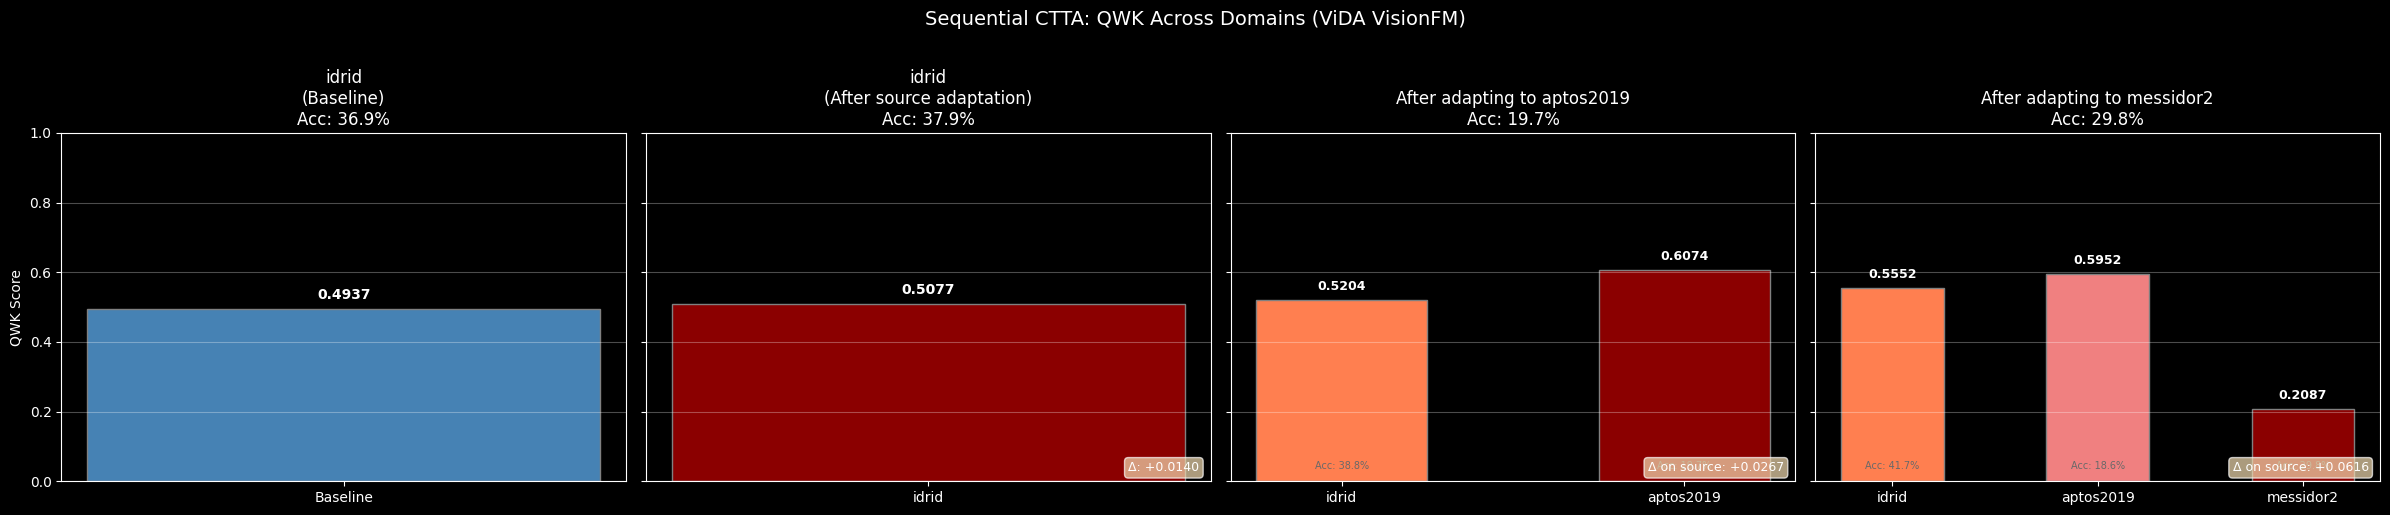

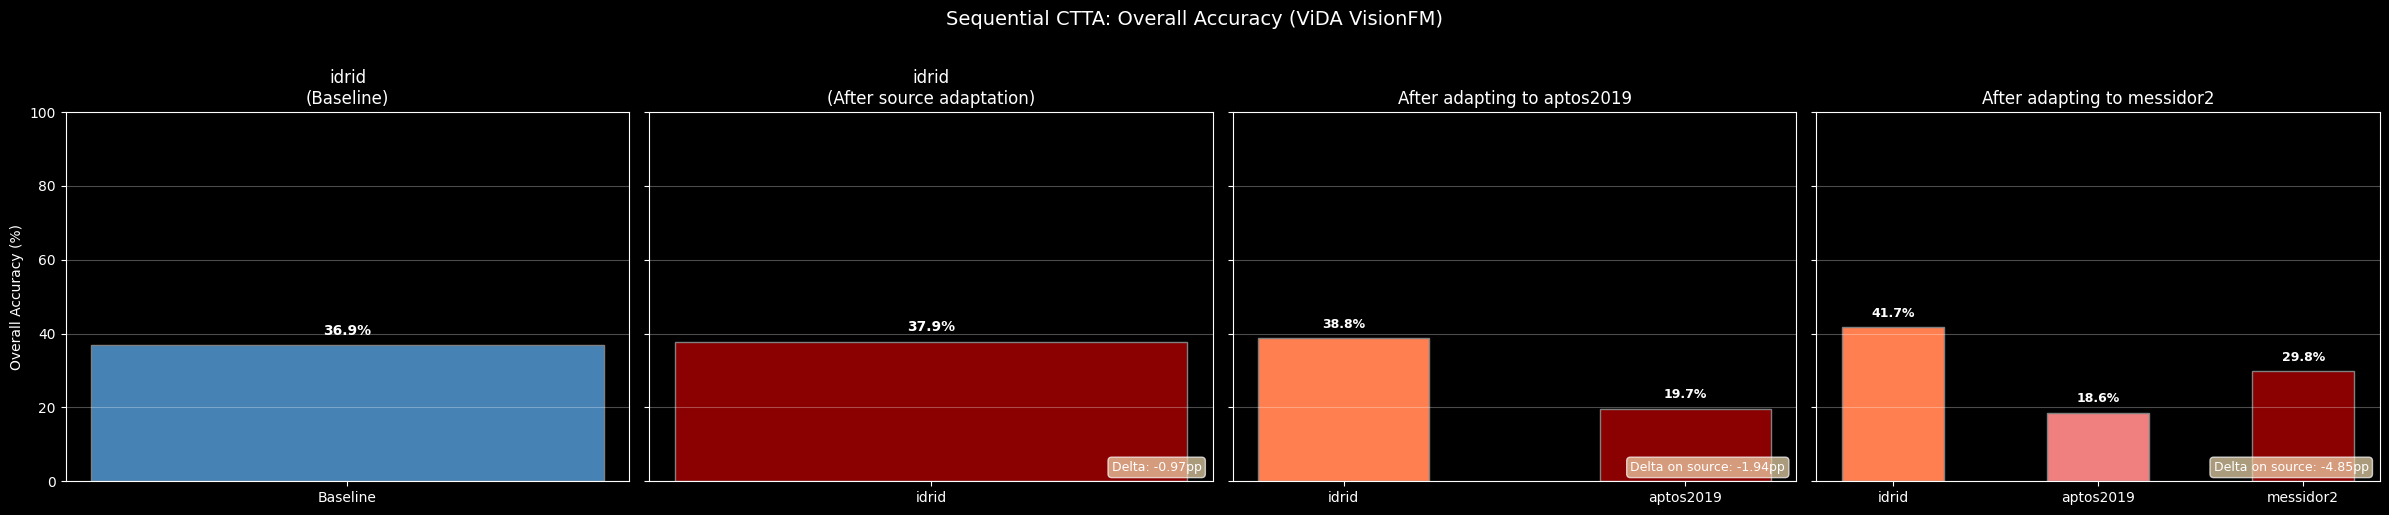

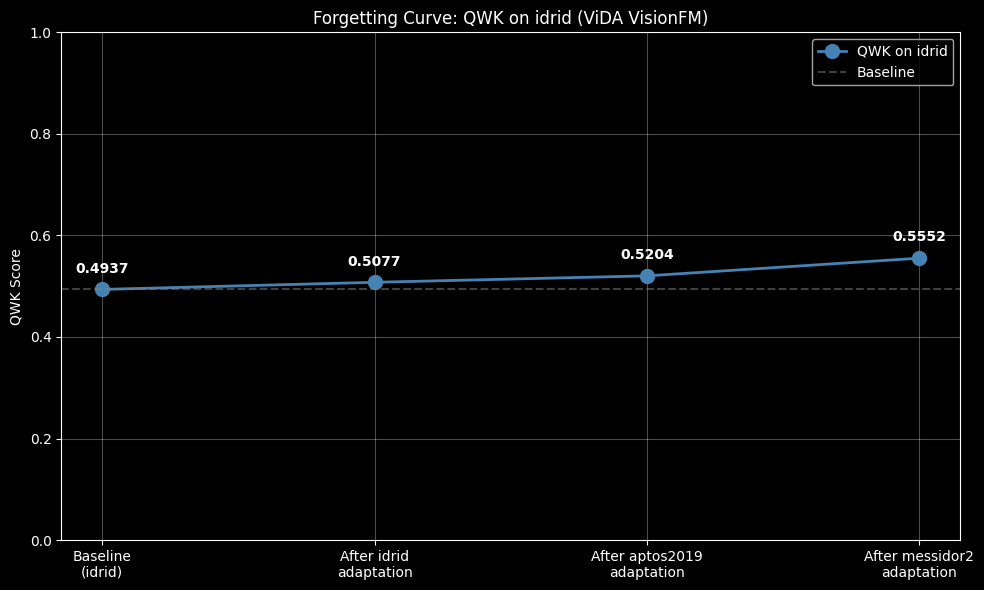

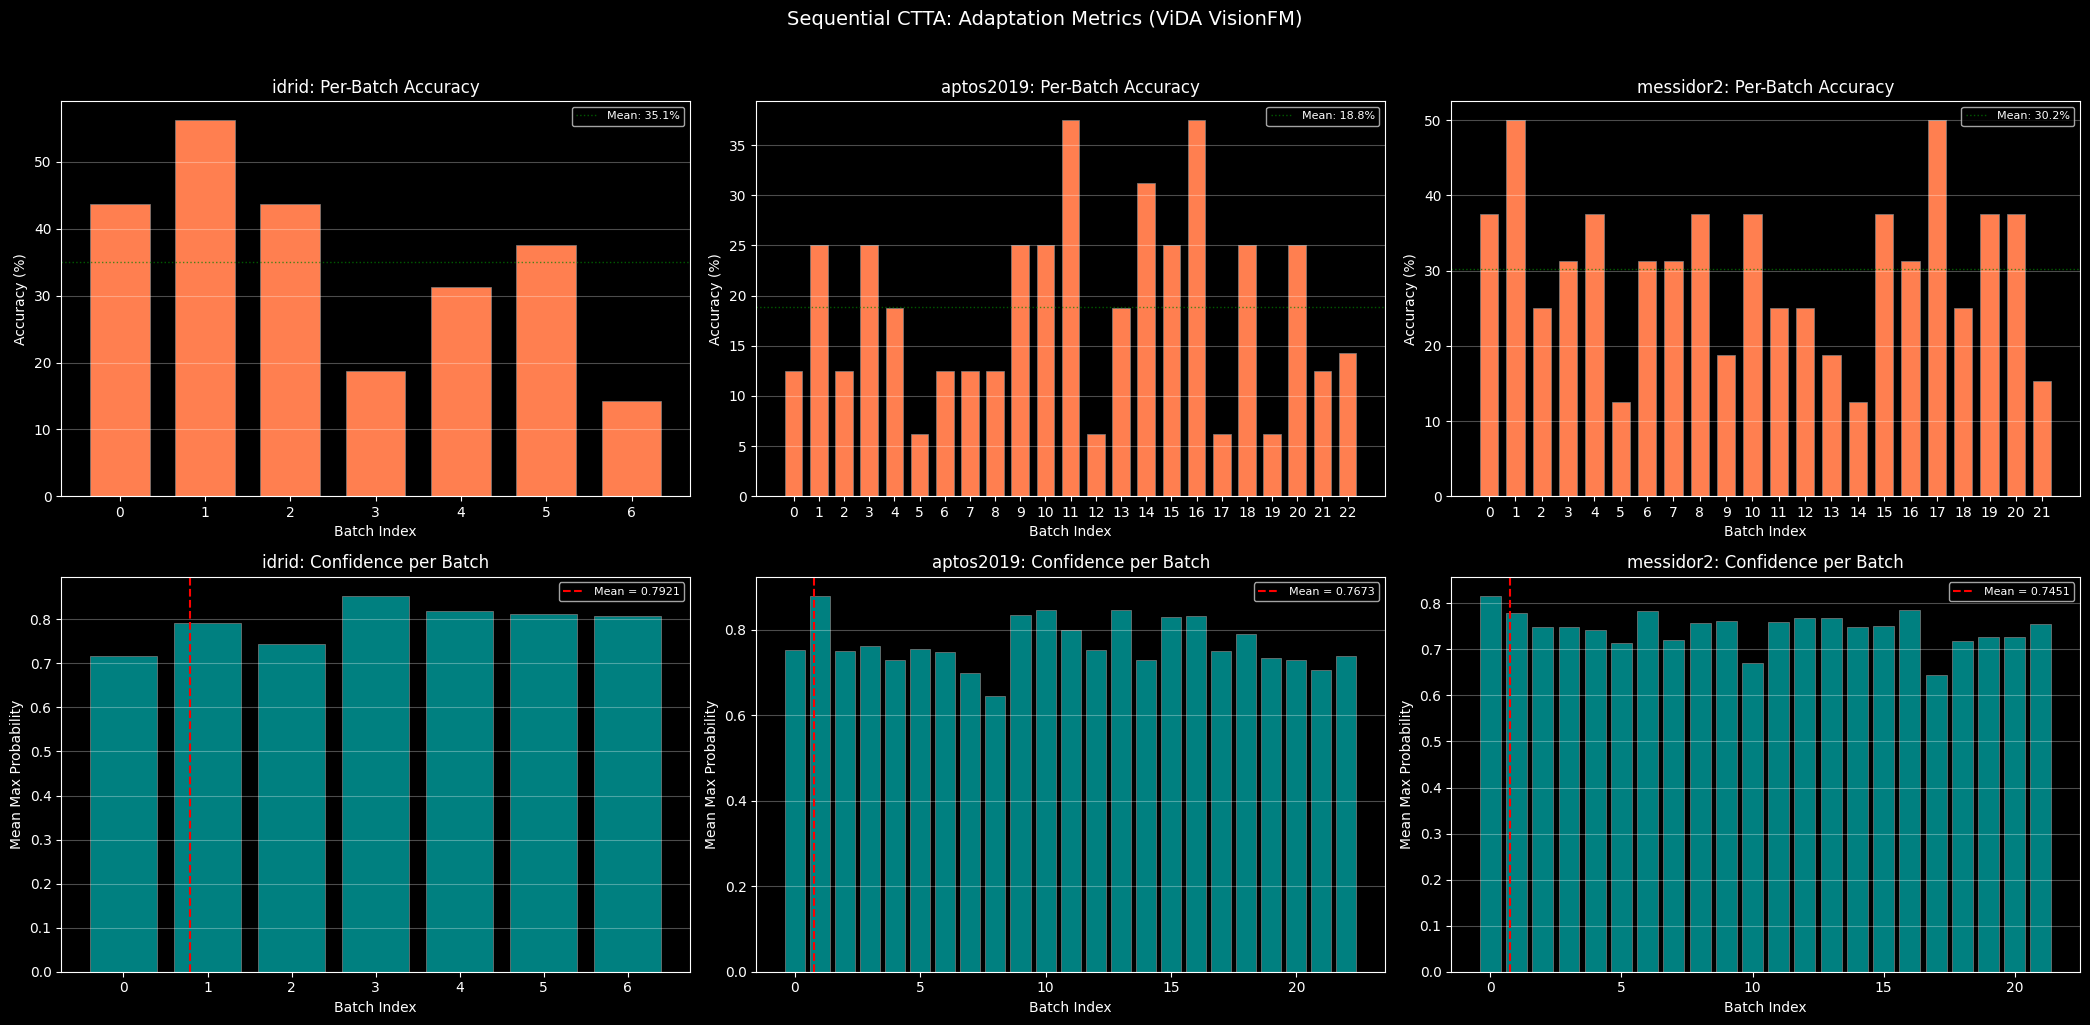

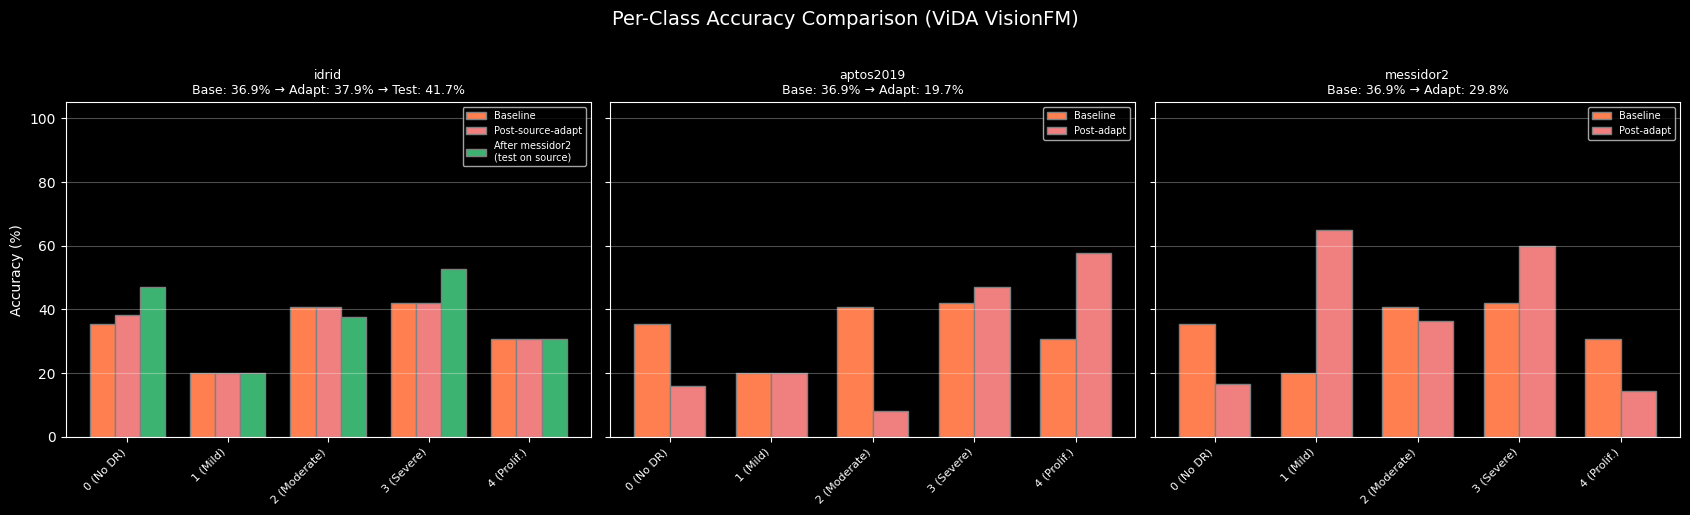

In [5]:
from pathlib import Path
from src.viz import (
    load_standalone_results,
    plot_sequential_qwk_comparison,
    plot_sequential_overall_accuracy,
    plot_sequential_forgetting,
    plot_sequential_adaptation_comparison,
    plot_sequential_per_class_accuracy,
    print_sequential_summary,
)

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

method_name = 'ViDA DINOv2' if config.model.name == 'retfound' else 'ViDA VisionFM'

print_sequential_summary(results, method_name=method_name)
plot_sequential_qwk_comparison(results, plots_dir, method_name=method_name)
plot_sequential_overall_accuracy(results, plots_dir, method_name=method_name)
plot_sequential_forgetting(results, plots_dir, method_name=method_name)
plot_sequential_adaptation_comparison(results, plots_dir, method_name=method_name)
plot_sequential_per_class_accuracy(results, plots_dir, method_name=method_name)